# A4 - A two-headed net: one trunk, a policy-like head and a value-like head

**This is the bridge to AlphaZero.** raccoon's network has a shared trunk feeding
**two heads**: a *policy* head (a probability distribution, trained with
cross-entropy) and a *value* head (a single number in [-1, 1] via `tanh`, trained
with MSE). The total loss is just their sum.

We build the *exact same skeleton* on MNIST: a classification head (predict the
digit, cross-entropy) and a regression head (predict the digit's magnitude in
[-1, 1], MSE). Same structure, friendlier data.

In [1]:
import inspect
from azl.foundations import models
print(inspect.getsource(models.TwoHeadedNet))

class TwoHeadedNet(nn.Module):
    """Shared trunk + classification head + regression head.

    forward(x) -> (class_logits, value)
        class_logits : (B, num_classes)  -- train with cross-entropy (like raccoon's POLICY head)
        value        : (B,)              -- tanh-bounded scalar in [-1, 1],
                                            train with MSE (like raccoon's VALUE head)

    Compare with :class:`azl.network.AZNet`: same skeleton, the only difference
    is the trunk's input shape and what the heads *mean* (move distribution vs
    digit class; position value vs digit magnitude).
    """

    def __init__(
        self,
        in_channels: int = 1,
        channels: int = 32,
        num_blocks: int = 3,
        num_classes: int = 10,
    ):
        super().__init__()
        self.trunk = ConvTrunk(in_channels, channels, num_blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.class_head = nn.Linear(channels, num_classes)
        self.value_head = nn.Li

In [2]:
import matplotlib.pyplot as plt
import torch

from azl.foundations.data import mnist_loaders, digit_to_value
from azl.foundations.models import TwoHeadedNet
from azl.foundations.train_loop import fit, evaluate, make_two_head_loss

torch.manual_seed(0)
train_loader, test_loader = mnist_loaders(batch_size=128, view="image", num_train=12000)

net = TwoHeadedNet(channels=32, num_blocks=3, num_classes=10)
loss_fn = make_two_head_loss(value_weight=1.0)   # cross_entropy(class) + MSE(value)
history = fit(net, train_loader, test_loader, epochs=3, lr=1e-3, compute_loss=loss_fn)
print("final class accuracy:", history["val_acc"][-1])

epoch  1/3  train_loss 1.8994  val_loss 1.3615  val_acc 0.7466


epoch  2/3  train_loss 0.9445  val_loss 0.7574  val_acc 0.8888


epoch  3/3  train_loss 0.5234  val_loss 0.5586  val_acc 0.9313
final class accuracy: 0.9313


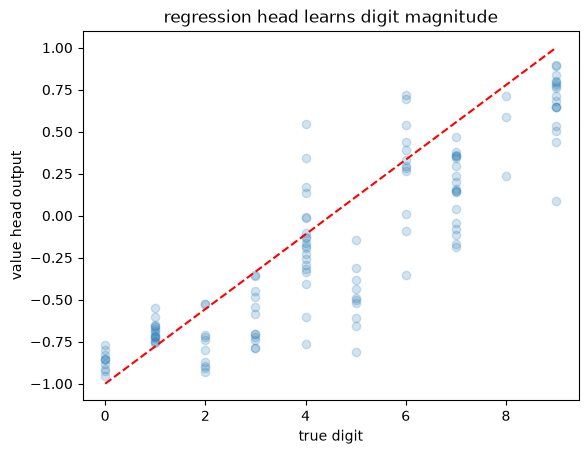

class accuracy on this batch: 0.9375


In [3]:
# Inspect both heads on a test batch: classification AND regression from one trunk.
net.eval()
x, y = next(iter(test_loader))
with torch.no_grad():
    logits, value = net(x)
pred_digit = logits.argmax(1)
plt.scatter(y.numpy(), value.numpy(), alpha=0.2)
plt.plot([0, 9], [digit_to_value(torch.tensor([0, 9]))[0], digit_to_value(torch.tensor([0, 9]))[1]], "r--")
plt.xlabel("true digit"); plt.ylabel("value head output"); plt.title("regression head learns digit magnitude"); plt.show()
print("class accuracy on this batch:", (pred_digit == y).float().mean().item())

### Maps to raccoon (the whole point)
Compare `TwoHeadedNet` with `azl.network.AZNet`:

| this notebook (A4)            | AlphaZero / raccoon                       |
|-------------------------------|-------------------------------------------|
| classification head + CE      | **policy** head + cross-entropy           |
| regression head (tanh) + MSE  | **value** head (tanh) + MSE               |
| loss = CE + MSE               | loss = policy_loss + value_loss           |
| shared conv trunk             | shared ResNet trunk                       |

The only real change in Track B is *what the heads mean*: instead of "which digit"
and "how big", they predict "which move" and "who's winning". You've now built
every architectural piece of raccoon's network on familiar data.